# QAWG multiplexed readout

This notebook builds two readout tones on one AWG channel and demodulates both
tones from the same ATS9371 voltage records.

The compiler currently owns one readout frequency, so multiplex acquisition
uses the lower-level boundaries intentionally:

1. `QAWG.awg5200` creates the summed waveform and marker.
2. `AWGAlazar.acquire_records(n_average=...)` captures unprocessed records.
3. `AlazarProcessor.process_multiplex_integrate(...)` extracts one IQ point
   per tone and per shot.

The preview and simulation sections do not require hardware. Only run the
hardware section when the AWG5208 and ATS9371 are connected.

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import importlib

import QAWG.awg_alazar as awg_alazar_module
from QAWG import ns, us
from QAWG.alazar import AlazarProcessor
from QAWG.awg5200 import (
    align_channel_envelopes,
    align_channels,
    delay,
    gaussian_square_ns,
    parallel,
    trigger_channel_for,
    waveform,
)

# Reload the local module so a long-running Jupyter kernel does not keep an
# AWGAlazar class imported before acquire_records() was added.
awg_alazar_module = importlib.reload(awg_alazar_module)
AWGAlazar = awg_alazar_module.AWGAlazar

print("QAWG hardware module:", awg_alazar_module.__file__)
print("Raw acquisition API available:", hasattr(AWGAlazar, "acquire_records"))

QAWG hardware module: c:\Users\cluster\Desktop\custmon\QAWG\awg_alazar.py
Raw acquisition API available: True


## Shared multiplex configuration

In [43]:
AWG_SAMPLE_RATE_HZ = 2.5e9
ALAZAR_SAMPLE_RATE_HZ = 1e9

READOUT_FREQUENCIES_HZ = {
    "q0": 50e6,
    "q1": 150e6,
}
REFERENCE_PHASES_RAD = {
    "q0": 0.0,
    "q1": 0.0,
}

AWG_SIGNAL_CHANNEL = 3
AWG_MARKER_CHANNEL = 1
CHANNEL_AMPLITUDE_VPP = 0.5
READOUT_START = 0 * ns
READOUT_LENGTH = 1 * us
EDGE_SIGMA = 20 * ns
STEP_LENGTH = 2 * us

# The two gains multiply the common envelope. Keep their summed peak within
# CHANNEL_AMPLITUDE_VPP / 2.
READOUT_GAINS = {
    "q0": 0.2,
    "q1": 0.1,
}

## Offline AWG waveform and marker preview

In [44]:
envelope = gaussian_square_ns(
    duration_ns=READOUT_LENGTH / ns,
    sample_rate_hz=AWG_SAMPLE_RATE_HZ,
    edge_sigma_ns=EDGE_SIGMA / ns,
    amplitude_volts=CHANNEL_AMPLITUDE_VPP / 2,
)

tones = [
    waveform(
        envelope,
        fc=frequency_hz,
        ch=AWG_SIGNAL_CHANNEL,
        phase_radians=REFERENCE_PHASES_RAD[name],
        name=name,
        gain=READOUT_GAINS[name],
    )
    for name, frequency_hz in READOUT_FREQUENCIES_HZ.items()
]
multiplex_timeline = (
    parallel(*tones)
    if READOUT_START == 0
    else delay(READOUT_START) / parallel(*tones)
)

channel_waveforms = align_channels(
    multiplex_timeline,
    sample_rate_hz=AWG_SAMPLE_RATE_HZ,
    total_duration_s=STEP_LENGTH,
)
channel_envelopes = align_channel_envelopes(
    multiplex_timeline,
    sample_rate_hz=AWG_SAMPLE_RATE_HZ,
    total_duration_s=STEP_LENGTH,
)
multiplex_waveform = channel_waveforms[AWG_SIGNAL_CHANNEL]
_, marker = trigger_channel_for(
    channel_envelopes[AWG_SIGNAL_CHANNEL],
    threshold_ratio=1e-3,
)
awg_time_ns = np.arange(multiplex_waveform.size) / AWG_SAMPLE_RATE_HZ / ns

print("Waveform samples:", multiplex_waveform.size)
print("Peak voltage:", np.max(np.abs(multiplex_waveform)))
print("Marker active samples:", np.count_nonzero(marker))

Waveform samples: 5000
Peak voltage: 0.053490186365830694
Marker active samples: 2470


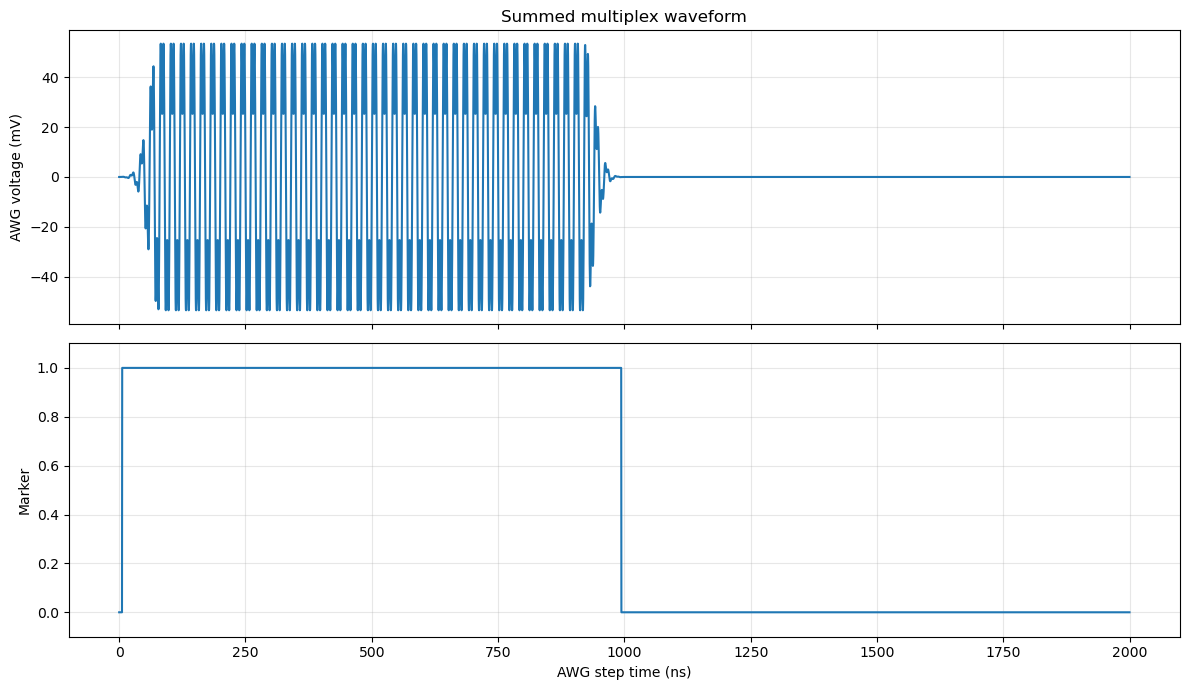

In [45]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(awg_time_ns, multiplex_waveform * 1e3)
axes[0].set_ylabel("AWG voltage (mV)")
axes[0].set_title("Summed multiplex waveform")
axes[0].grid(True, alpha=0.3)

axes[1].plot(awg_time_ns, marker.astype(int))
axes[1].set_xlabel("AWG step time (ns)")
axes[1].set_ylabel("Marker")
axes[1].set_ylim(-0.1, 1.1)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Offline DSP check

This simulation verifies the multiplex demodulation independently of the
hardware connection. Each real input tone is mixed to complex baseband and
integrated over the selected readout window.

In [46]:
SIMULATED_SHOTS = 500
ACQUIRE_WINDOW = 1.5 * us
INTEGRATE_WINDOW = (100 * ns, 1100 * ns)

record_samples = int(round(ACQUIRE_WINDOW * ALAZAR_SAMPLE_RATE_HZ))
adc_time_s = np.arange(record_samples) / ALAZAR_SAMPLE_RATE_HZ
window = np.zeros(record_samples)
start = int(round(INTEGRATE_WINDOW[0] * ALAZAR_SAMPLE_RATE_HZ))
stop = int(round(INTEGRATE_WINDOW[1] * ALAZAR_SAMPLE_RATE_HZ))
window[start:stop] = 1.0

simulated = (
    0.08
    * window
    * np.cos(2 * np.pi * READOUT_FREQUENCIES_HZ["q0"] * adc_time_s + 0.4)
    + 0.04
    * window
    * np.cos(2 * np.pi * READOUT_FREQUENCIES_HZ["q1"] * adc_time_s - 0.6)
)
rng = np.random.default_rng(42)
simulated_records = simulated + rng.normal(
    0.0,
    0.015,
    size=(SIMULATED_SHOTS, record_samples),
)

processor = AlazarProcessor(ALAZAR_SAMPLE_RATE_HZ)
simulated_results = processor.process_multiplex_integrate(
    records_volts=simulated_records,
    tone_frequencies_hz=READOUT_FREQUENCIES_HZ,
    reference_phases_radians=REFERENCE_PHASES_RAD,
    integrate_start=start,
    integrate_stop=stop,
)

for name, (_, shot_iq, average_iq) in simulated_results.items():
    print(
        name,
        "shots:",
        shot_iq.shape,
        "average IQ:",
        average_iq,
    )

q0 shots: (500,) average IQ: (0.07370758751139533+0.0311732818898706j)
q1 shots: (500,) average IQ: (0.03305344451542142-0.022566445236504338j)


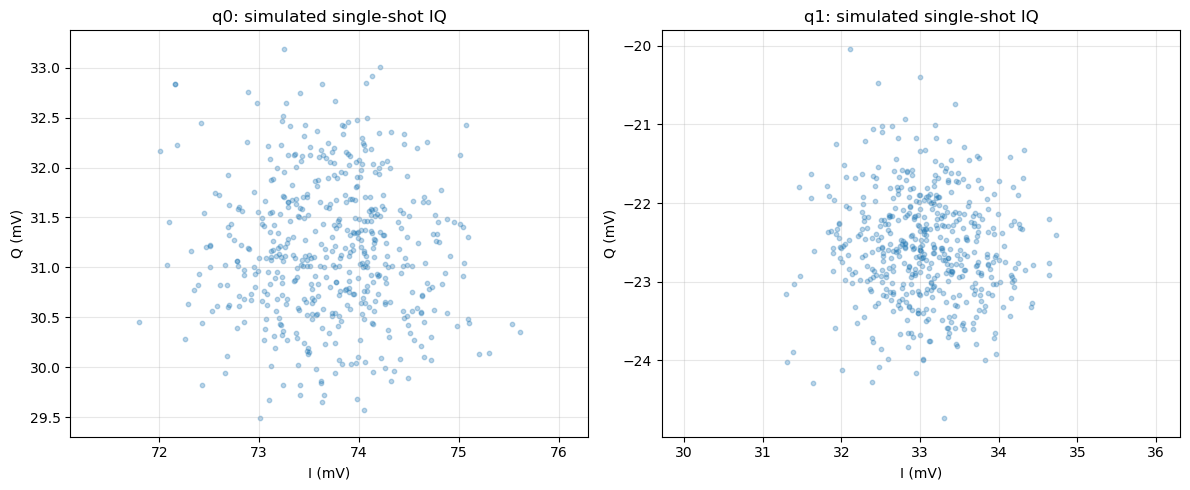

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for axis, name in zip(axes, READOUT_FREQUENCIES_HZ):
    shots = simulated_results[name][1] * 1e3
    axis.scatter(shots.real, shots.imag, s=10, alpha=0.3)
    axis.set_xlabel("I (mV)")
    axis.set_ylabel("Q (mV)")
    axis.set_title(f"{name}: simulated single-shot IQ")
    axis.axis("equal")
    axis.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Real hardware setup

Wiring:

```text
AWG channel 3 analog output -> readout path -> ATS9371 CHB
AWG channel 1 marker 1     -> ATS9371 external trigger
```

Like `demo.ipynb`, averaging is an acquisition argument. It is not passed to
`AWGAlazar.connect()`.

In [48]:
AWG_RESOURCE = "TCPIP0::192.168.10.171::inst0::INSTR"
ADC_CHANNEL = "CHB"
HARDWARE_ACQUIRE_WINDOW = 1.5 * us
INTEGRATE_WINDOW = (100 * ns, 1100 * ns)
N_AVERAGE = 1000

if not hasattr(AWGAlazar, "acquire_records"):
    raise RuntimeError(
        "This kernel has an older AWGAlazar class. Restart the kernel and "
        "run all cells from the beginning."
    )

experiment = AWGAlazar.connect(
    AWG_RESOURCE,
    awg_sample_rate_hz=AWG_SAMPLE_RATE_HZ,
    alazar_sample_rate_hz=ALAZAR_SAMPLE_RATE_HZ,
    acquire_window_s=HARDWARE_ACQUIRE_WINDOW,
    trigger_slope="rising",
    trigger_level=140,
    tone_frequency_hz=READOUT_FREQUENCIES_HZ["q0"],
    trigger_delay_s=0,
    integrate_window_ns=(
        INTEGRATE_WINDOW[0] / ns,
        INTEGRATE_WINDOW[1] / ns,
    ),
    adc_channel=ADC_CHANNEL,
    moving_average_time_s=20 * ns,
    timeout_ms=60_000,
    use_external_10mhz_reference=True,
)

print("Connected:", experiment.awg.identify())
print("ADC channel:", experiment.adc_channel_name)
print("Acquire samples:", experiment.acquire_window_cycles)

Connected: TEKTRONIX,AWG5208,B030598,FV:6.6.0131.0
ADC channel: CHB
Acquire samples: 1536


## Upload one multiplex waveform

In [49]:
def upload_multiplexed_readout(
    phases_rad,
    gains=READOUT_GAINS,
    name="multiplex",
):
    envelope = gaussian_square_ns(
        duration_ns=READOUT_LENGTH / ns,
        sample_rate_hz=experiment.awg_sample_rate_hz,
        edge_sigma_ns=EDGE_SIGMA / ns,
        amplitude_volts=CHANNEL_AMPLITUDE_VPP / 2,
    )
    pulses = [
        waveform(
            envelope,
            fc=frequency_hz,
            ch=AWG_SIGNAL_CHANNEL,
            phase_radians=phases_rad[name],
            name=f"{name}_{name}",
            gain=gains[name],
        )
        for name, frequency_hz in READOUT_FREQUENCIES_HZ.items()
    ]
    timeline = (
        parallel(*pulses)
        if READOUT_START == 0
        else delay(READOUT_START) / parallel(*pulses)
    )
    uploaded = experiment.awg.upload_timeline(
        timeline,
        amplitude_vpp={AWG_SIGNAL_CHANNEL: CHANNEL_AMPLITUDE_VPP},
        name_prefix=name,
        total_duration_s=STEP_LENGTH,
    )
    marker_name = experiment.awg.marker(
        waveform_ch=AWG_SIGNAL_CHANNEL,
        marker_ch=AWG_MARKER_CHANNEL,
        marker_number=1,
        low_volts=0.0,
        high_volts=1.2,
        amplitude_vpp=CHANNEL_AMPLITUDE_VPP,
    )
    return uploaded, marker_name


upload_multiplexed_readout(
    phases_rad={"q0": 0.0, "q1": 0.0},
    name="state_00",
)

({3: 'state_00_ch3'}, 'marker_ch1_for_ch3')

## Acquire raw records and demodulate both tones

`acquire_records()` arms the ATS9371, runs the AWG, and returns one raw voltage
record per trigger. The same records are then processed at both frequencies.

In [40]:
raw_time_s, records = experiment.acquire_records(n_average=N_AVERAGE)
integrate_start, integrate_stop = experiment.integrate_window_cycles

hardware_results = experiment.processor.process_multiplex_integrate(
    records_volts=records,
    tone_frequencies_hz=READOUT_FREQUENCIES_HZ,
    reference_phases_radians=REFERENCE_PHASES_RAD,
    integrate_start=integrate_start,
    integrate_stop=integrate_stop,
)

print("Raw records:", records.shape)
for name, (_, shot_iq, average_iq) in hardware_results.items():
    print(name, shot_iq.shape, average_iq)

Raw records: (1000, 1536)
q0 (1000,) (4.790939514589285e-05-2.5408274398045428e-05j)
q1 (1000,) (-5.828604562091586e-06+2.3172469943904616e-05j)


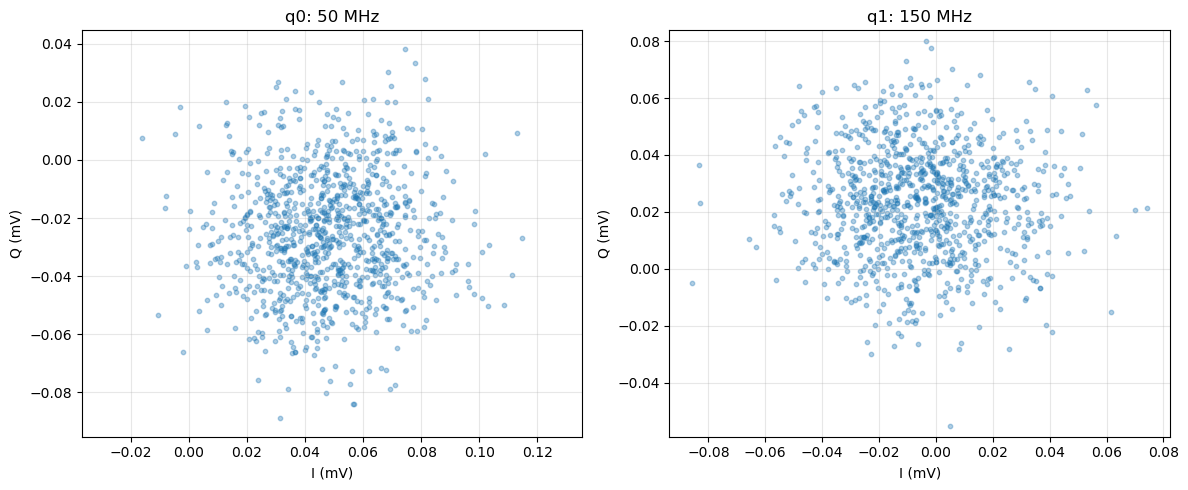

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for axis, name in zip(axes, READOUT_FREQUENCIES_HZ):
    shots_mv = hardware_results[name][1] * 1e3
    axis.scatter(shots_mv.real, shots_mv.imag, s=10, alpha=0.35)
    axis.set_xlabel("I (mV)")
    axis.set_ylabel("Q (mV)")
    axis.set_title(
        f"{name}: {READOUT_FREQUENCIES_HZ[name] / 1e6:.0f} MHz"
    )
    axis.axis("equal")
    axis.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Optional two-state comparison

This repeats the acquisition after changing both carrier phases from 0 to
180 degrees. Every state keeps its own single-shot records.

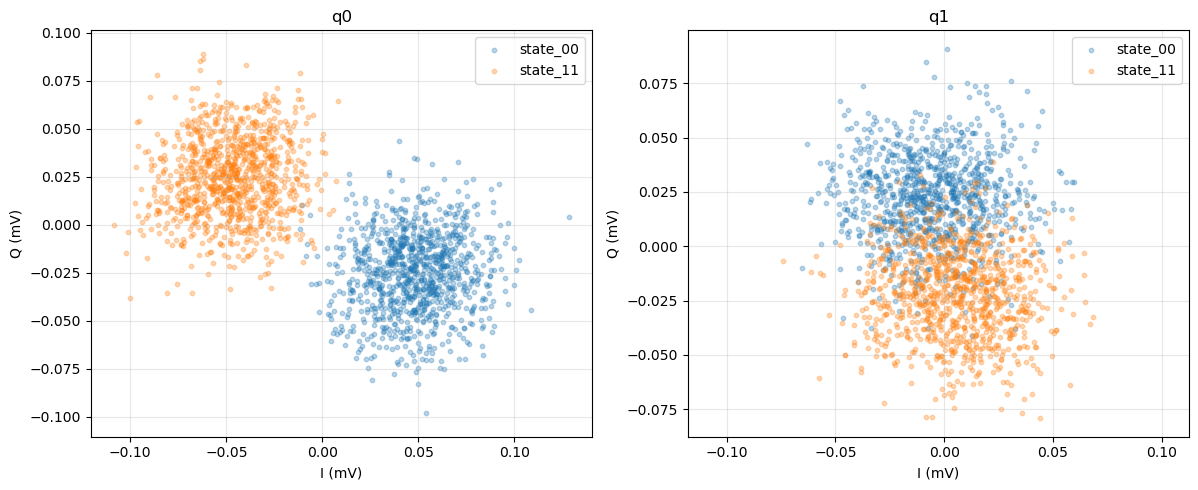

In [42]:
state_records = {}
for state_name, phase in {
    "state_00": 0.0,
    "state_11": np.pi,
}.items():
    upload_multiplexed_readout(
        phases_rad={"q0": phase, "q1": phase},
        name=state_name,
    )
    _, state_records[state_name] = experiment.acquire_records(
        n_average=N_AVERAGE,
    )

state_results = {
    state_name: experiment.processor.process_multiplex_integrate(
        records_volts=records,
        tone_frequencies_hz=READOUT_FREQUENCIES_HZ,
        reference_phases_radians=REFERENCE_PHASES_RAD,
        integrate_start=integrate_start,
        integrate_stop=integrate_stop,
    )
    for state_name, records in state_records.items()
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = {"state_00": "tab:blue", "state_11": "tab:orange"}
for axis, tone_name in zip(axes, READOUT_FREQUENCIES_HZ):
    for state_name in state_results:
        shots_mv = state_results[state_name][tone_name][1] * 1e3
        axis.scatter(
            shots_mv.real,
            shots_mv.imag,
            s=10,
            alpha=0.3,
            color=colors[state_name],
            label=state_name,
        )
    axis.set_xlabel("I (mV)")
    axis.set_ylabel("Q (mV)")
    axis.set_title(tone_name)
    axis.axis("equal")
    axis.grid(True, alpha=0.3)
    axis.legend()

plt.tight_layout()
plt.show()

## Close hardware

In [ ]:
experiment.close()